# Circuit Clustering Analysis - F1 Strategy Manager

## The importance of Understanding Circuit Types in F1

In Formula 1, not all circuits are equal. From the narrow streets of Monaco to the long straights of Monza, each track presents unique characteristics that directly impact race strategy and car's performance.

According to analyses from teams like **Mercedes AMG F1** and technical studies from the oficcial tire supplier **Pirelli**, circuits can be classified into categories that determine: 

- *Tire Strategies*: 1,2 or 3 stops depending on degradation.
- *Aerodynamic Configurations*: high downforce like monaco or low downforce like Monza.
- *Undercut/overcut windows*: Optimal pit stop timing to gain a free overtake on the rivals.
- *Thermal management*: tire and brake temperatures.

### Traditional Classifications

Historically, F1 analyst classify circuits into categories such as:

- *Street Circuits*: traditionally slow and technical like Monaco or Singapore, but also mixed like Baku, with a long straight but also with a technical section with slow turns. 
- *High Speed*: fast, with few slow corners and normally with low downforce, such as Spa, Monza or Silverstone.
- *Traditional/Balanced*: circuits with a balanced mix, such as Bahrain, Barcelona or Suzuka.
- *Hot & Abrasive*: circuits that have high thermal degradation, like Qatar.

### Objective of this analysis

Our objective is to **identify groups of similar circuits** using **unsupervised clustering (K-Means)**, utilizing quantifiable characteristics extracted from the 46 races analyzed in the previous notebook. Finally, we'll validate our results againts traditional F1 classifications.

### *Some useful references*

- [FIA Circuit Regulations](https://www.fia.com/regulation/category/123)
- [Formula 1 Technical Regulations](https://www.fia.com/regulation/category/110)

---

## Importing Libraries

In [1]:
## Data Manipulation
import pandas as pd
import numpy as np

## Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
## Statistics
from scipy import stats
from scipy.spatial.distance import cdist

## File Handling 
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

# Plotting style
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


## Setting Up Paths

In [3]:
# Find repository root (where .git folder is)
current_path = Path.cwd()
while not (current_path / ".git").exists() and current_path != current_path.parent:
    current_path = current_path.parent
REPO_ROOT = current_path

# Configure absolute paths from repository root
RAW_DATA_PATH        = REPO_ROOT / "data" / "raw"
OUTPUTS_PATH         = REPO_ROOT / "notebooks" / "data_engineering" / "outputs"

# Create outputs directory if it doesn't exist
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Repository root:  {REPO_ROOT}")
print(f"Raw data path:    {RAW_DATA_PATH}")
print(f"Outputs path:     {OUTPUTS_PATH}")

Repository root:  c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
Raw data path:    c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\raw
Outputs path:     c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\data_engineering\outputs


---

## Step 1: Data Loading

We'll reuse the data loading functions from Phase 2.2 (Master EDA) to load all 46 Grand Prix races. This provides us with the master DataFrames containing laps, intervals, weather, and pit stops data across both 2023 and 2024 seasons.

Unfortunately, we can't import functions from other notebooks, so I'll add them again here. The functions are:
- `load_single_gp()`
- `combine_master_dataframes()`
- `load_all_races()`


In [4]:
def load_single_gp(gp_path: Path, year: str, gp_name: str) -> dict:
    """
    Load data for a single Grand Prix.
    
    Parameters:
    - gp_path: Path to GP directory
    - year: Year as string
    - gp_name: GP name
    
    Returns:
    - dict with 'laps', 'intervals', 'weather', 'pitstops' DataFrames, or None if failed
    """
    try:
        # Define file paths
        laps_file = gp_path / "laps.parquet"
        intervals_file = gp_path / "intervals.parquet"
        weather_file = gp_path / "weather.parquet"
        pitstops_file = gp_path / "pitstops.parquet"
        
        # Check if all files exist
        if not all([laps_file.exists(), intervals_file.exists(), 
                   weather_file.exists(), pitstops_file.exists()]):
            print(f"  WARNING: {gp_name}: Missing files, skipping...")
            return None
        
        # Load data
        laps_df = pd.read_parquet(laps_file)
        intervals_df = pd.read_parquet(intervals_file)
        weather_df = pd.read_parquet(weather_file)
        pitstops_df = pd.read_parquet(pitstops_file)
        
        # Add metadata columns
        for df in [laps_df, intervals_df, weather_df, pitstops_df]:
            df['GP_Name'] = gp_name
            df['Year'] = int(year)
        
        return {
            'laps': laps_df,
            'intervals': intervals_df,
            'weather': weather_df,
            'pitstops': pitstops_df
        }
        
    except Exception as e:
        print(f"  ERROR: {gp_name}: Error loading data - {str(e)}")
        return None

In [5]:
def combine_master_dataframes(all_laps: list, all_intervals: list, 
                              all_weather: list, all_pitstops: list) -> tuple:
    """
    Combine and sort all GP DataFrames into master DataFrames.
    
    Parameters:
    - all_laps, all_intervals, all_weather, all_pitstops: Lists of DataFrames
    
    Returns:
    - Tuple of (laps_master, intervals_master, weather_master, pitstops_master)
    """
    # Concatenate all DataFrames
    laps_master = pd.concat(all_laps, ignore_index=True)
    intervals_master = pd.concat(all_intervals, ignore_index=True)
    weather_master = pd.concat(all_weather, ignore_index=True)
    pitstops_master = pd.concat(all_pitstops, ignore_index=True)
    
    # Sort DataFrames
    laps_master = laps_master.sort_values(
        ['Year', 'GP_Name', 'DriverNumber', 'LapNumber']
    ).reset_index(drop=True)
    
    intervals_master = intervals_master.sort_values(
        ['Year', 'GP_Name', 'date']
    ).reset_index(drop=True)
    
    weather_master = weather_master.sort_values(
        ['Year', 'GP_Name', 'Time']
    ).reset_index(drop=True)
    
    pitstops_master = pitstops_master.sort_values(
        ['Year', 'GP_Name', 'LapNumber']
    ).reset_index(drop=True)
    
    return laps_master, intervals_master, weather_master, pitstops_master

In [6]:
def load_all_races() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Load all Grand Prix races from parquet files and combine into master DataFrames.
    
    Returns:
    - laps_master: Combined lap data from all GPs
    - intervals_master: Combined interval data from all GPs
    - weather_master: Combined weather data from all GPs
    - pitstops_master: Combined pit stop data from all GPs
    """
    print("Loading all race data...")
    print("=" * 60)
    
    # Initialize lists
    all_laps = []
    all_intervals = []
    all_weather = []
    all_pitstops = []
    
    # Track statistics
    loaded_gps = 0
    
    # Scan all year directories
    for year_path in sorted(RAW_DATA_PATH.glob("*")):
        if not year_path.is_dir():
            continue
        
        year = year_path.name
        
        # Scan all GP directories in this year
        for gp_path in sorted(year_path.glob("*")):
            if not gp_path.is_dir():
                continue
            
            gp_name = gp_path.name.replace('_', ' ')
            
            # Load single GP
            gp_data = load_single_gp(gp_path, year, gp_name)
            
            if gp_data is None:
                continue
            
            # Append to lists
            all_laps.append(gp_data['laps'])
            all_intervals.append(gp_data['intervals'])
            all_weather.append(gp_data['weather'])
            all_pitstops.append(gp_data['pitstops'])
            loaded_gps += 1
    
    # Combine all DataFrames
    print("=" * 60)
    laps_master, intervals_master, weather_master, pitstops_master = combine_master_dataframes(
        all_laps, all_intervals, all_weather, all_pitstops
    )
    
    # Summary
    print(f"\nSuccessfully loaded {loaded_gps} GPs")
    print(f"\nMaster DataFrames created:")
    print(f"  Laps:      {len(laps_master):,} rows")
    print(f"  Intervals: {len(intervals_master):,} rows")
    print(f"  Weather:   {len(weather_master):,} rows")
    print(f"  Pitstops:  {len(pitstops_master):,} rows")
    print("=" * 60)
    
    return laps_master, intervals_master, weather_master, pitstops_master


#### Load Data

In [7]:
laps_master, intervals_master, weather_master, pitstops_master = load_all_races()

Loading all race data...

Successfully loaded 47 GPs

Master DataFrames created:
  Laps:      52,340 rows
  Intervals: 1,111,904 rows
  Weather:   7,463 rows
  Pitstops:  1,835 rows


---

## Step 2: Feature Engineering - Extracting Circuit DNA

To intelligently group circuits, we need to quantify their characteristics. Based on F1 technical analyses and **Pirelli's tire performance studies**, we identify **4 key dimensions** that define a circuit's nature:

### 2.1 Speed & Complexity

Circuit layout characteristics that determine lap time and racing difficulty:

- **Mean lap time**: Fast circuits (Monza ~1:21) vs slow circuits (Monaco ~1:12)
- **Lap time variability**: Higher variance indicates more traffic, overtaking opportunities, or technical complexity
- **Fastest lap**: Pure pace potential of the circuit

### 2.2 Tire Degradation
How aggressively the circuit wears tires, impacting strategy:
- **Degradation rate**: Linear regression slope of lap time vs tire age
- **Stint length capability**: Maximum tire life observed (how long tires last)
- **Lap time variance per stint**: Higher variance = higher degradation

### 2.3 Pit Stop Strategy
Strategic patterns that emerge from circuit characteristics:
- **Average pit stops per driver**: 1-stop (Spa) vs 3-stop (Qatar) strategies
- **Pit stop timing variability**: Does everyone stop at similar laps, or is it flexible?

### 2.4 Environmental Conditions
Weather and elevation factors affecting performance:
- **Track temperature**: Impacts tire degradation (Pirelli optimal window: 80-110°C)
- **Air temperature**: Affects engine cooling and aerodynamic grip
- **Atmospheric pressure**: Proxy for elevation (Mexico City at 2,200m vs sea level)

### **References:**
- [Pirelli F1 Technical Insights](https://press.pirelli.com/category/formula-1/)
- [F1 Technical: Circuit Classification Methods](https://www.formula1.com/)

### 2.1 Extracting Speed & Complexity Features

We calculate lap time statistics per circuit, filtering out outliers (safety car laps >180s).


In [8]:
def extract_speed_complexity_features(laps_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract speed and complexity features for each circuit.
    
    Features:
    - mean_laptime: Average lap time (seconds)
    - std_laptime: Lap time standard deviation (variability)
    - min_laptime: Fastest lap time (pure pace)
    
    Parameters:
    - laps_df: Master laps DataFrame
    
    Returns:
    - DataFrame with circuit-level features
    """
    # Filter racing laps (<180s to exclude safety car/red flags)
    racing_laps = laps_df[laps_df['LapTime'].notna()].copy()
    racing_laps['LapTime_seconds'] = racing_laps['LapTime'].dt.total_seconds()
    racing_laps = racing_laps[racing_laps['LapTime_seconds'] < 180]
    
    # Group by circuit and calculate statistics
    circuit_speed = racing_laps.groupby('GP_Name').agg({
        'LapTime_seconds': ['mean', 'std', 'min', 'count']
    }).reset_index()
    
    circuit_speed.columns = ['GP_Name', 'mean_laptime', 'std_laptime', 'min_laptime', 'n_laps']
    
    return circuit_speed

In [9]:
# Extract features
circuit_speed_features = extract_speed_complexity_features(laps_master)
print("Speed & Complexity Features:")
print(circuit_speed_features.sort_values('mean_laptime').to_string(index=False))

Speed & Complexity Features:
          GP_Name  mean_laptime  std_laptime  min_laptime  n_laps
        Spielberg        72.727        7.102       67.012    2757
        Zandvoort        80.911       11.321       73.817    2736
            Spain        81.104        3.982       76.330    1312
        Barcelona        81.289        3.855       76.330    2622
            Imola        82.688        3.739       78.589    1237
           Monaco        82.811        8.841       74.165    2722
        São Paulo        84.110       12.663       72.486    2186
         Budapest        85.312        3.639       80.305    2607
        Melbourne        85.780        9.341       79.813    1896
         Montréal        86.339       13.172       74.481    2581
      Mexico City        86.437       11.253       78.336    2465
            Monza        86.748        4.055       81.432    1956
       Yas Island        91.056        4.918       85.637    2190
           Lusail        94.376       16.738   

### **What this output means**

The speed and complexity features reveal expected patterns in F1 circuit design. **Spielberg (Red Bull Ring)** emerges as the fastest circuit with an average lap time of just 72.7 seconds, consistent with its short layout and high-speed nature. On the opposite end, **Spa-Francorchamps** shows the longest lap times at 112.1 seconds, reflecting its status as the longest circuit on the F1 calendar at 7.004 km.

Interestingly, **variability (std_laptime)** reveals strategic complexity: **Lusail (Qatar)** shows the highest variance (16.7s), suggesting significant variations in pace due to tire degradation or safety car interventions. Similarly, **Montréal** (13.2s) and **Shanghai** (13.8s) show high variability, possibly due to their technical sections creating larger performance gaps between cars. In contrast, circuits like **Barcelona** (3.9s std) and **Budapest** (3.6s std) show more consistent lap times, indicating predictable racing conditions.

This classification aligns with known F1 characteristics: short, flowing circuits (Spielberg, Zandvoort) are fastest, while long circuits with technical sections (Spa, Baku, Singapore) produce slower average times.

### 2.2 Extracting Tire Degradation Features

Tire degradation is crucial for strategy. We calculate:
- **Degradation rate**: How much lap time increases per lap of tire age (linear regression slope)
- **Maximum stint length**: Longest tire stint observed (tire durability)
- **Lap time variance per stint**: Higher variance indicates more pronounced degradation


In [10]:
def extract_tire_degradation_features(laps_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract tire degradation features for each circuit.
    
    Features:
    - degradation_rate: Linear regression slope of laptime vs tire age (seconds per lap)
      NOTE: This captures COMBINED effect of tire degradation (+) and fuel load (-)
      Future work: Normalize by FuelLoad to isolate pure tire degradation (see legacy)
    - max_stint_length: Maximum tire life observed (laps)
    - stint_variance: Variance of lap times within stints (degradation indicator)
    
    Parameters:
    - laps_df: Master laps DataFrame
    
    Returns:
    - DataFrame with circuit-level degradation features
    """
    # Filter racing laps with valid tire life
    racing_laps = laps_df[
        (laps_df['LapTime'].notna()) & 
        (laps_df['TyreLife'].notna())
    ].copy()
    racing_laps['LapTime_seconds'] = racing_laps['LapTime'].dt.total_seconds()
    racing_laps = racing_laps[racing_laps['LapTime_seconds'] < 180]
    
    circuit_degradation = []
    
    for circuit in racing_laps['GP_Name'].unique():
        circuit_data = racing_laps[racing_laps['GP_Name'] == circuit]
        
        # Calculate degradation rate (linear regression slope)
        # NO filtering by tire age - we want to capture degradation cliffs too
        if len(circuit_data) > 50:  # Need enough data points
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                circuit_data['TyreLife'], 
                circuit_data['LapTime_seconds']
            )
            degradation_rate = slope
        else:
            degradation_rate = np.nan
        
        # Maximum stint length
        max_stint = circuit_data['TyreLife'].max()
        
        # Stint variance (within-stint lap time variability)
        stint_variance = circuit_data.groupby(['Year', 'DriverNumber', 'Stint'])['LapTime_seconds'].var().mean()
        
        circuit_degradation.append({
            'GP_Name': circuit,
            'degradation_rate': degradation_rate,
            'max_stint_length': max_stint,
            'stint_variance': stint_variance
        })
    
    return pd.DataFrame(circuit_degradation)

In [11]:
# Extract degradation features
circuit_degradation_features = extract_tire_degradation_features(laps_master)
print("Tire Degradation Features:")
print(circuit_degradation_features.sort_values('degradation_rate', ascending=False).to_string(index=False))

Tire Degradation Features:
          GP_Name  degradation_rate  max_stint_length  stint_variance
            Imola            -0.047            54.000          21.385
       Marina Bay            -0.062            49.000          47.859
         Budapest            -0.085            43.000          12.811
            Monza            -0.089            43.000          20.011
             Baku            -0.124            52.000          32.347
        Barcelona            -0.131            50.000          13.778
            Spain            -0.134            50.000          15.189
        Melbourne            -0.152            53.000         112.835
           Monaco            -0.153            78.000          55.168
            Miami            -0.153            54.000          50.812
       Yas Island            -0.165            45.000          29.812
Spa-Francorchamps            -0.176            34.000          15.241
        Spielberg            -0.214            37.000          

#### **Analysis Paragraph**

The tire degradation features reveal an important insight: **most circuits show negative degradation rates**, indicating that the **fuel load effect dominates over pure tire degradation**. This is a well-documented phenomenon in F1 analysis - as explained by professional F1 analysts, *"most drivers actually get faster as the tyre life increases due to a loss of weight as fuel gets used"* ([Formula1Math - Tire Degradation Analysis](https://formula1math.substack.com/p/a-deep-dive-into-tyre-degradation)).

As cars burn fuel throughout a stint (becoming ~0.03s/lap faster per kg), this effect often outweighs the tire wear penalty. This is particularly pronounced at:

- **Lusail** (-0.870 s/lap): Extreme fuel sensitivity, likely due to long straights where weight matters most
- **Shanghai** (-0.489) and **Suzuka** (-0.440): High-speed circuits where fuel load significantly impacts performance
- **Marina Bay** (-0.062) and **Imola** (-0.047): Lowest negative rates, suggesting tire degradation is more balanced with fuel effect

**Fuel correction methodology:** Professional F1 analysts apply **fuel correction of 0.03 seconds per kg**, normalizing all lap times to a constant **110 kg fuel load** to isolate pure tire degradation ([F1Pace - 2024 Season Analysis](https://f1pace.com/p/2024-f1-season-tire-degradation-discussion-rounds-1-5/)). For circuit clustering purposes, the combined effect (fuel + degradation) is acceptable as it represents the circuit's overall strategic characteristic. However, for **Phase 2.4 Feature Engineering** and degradation modeling, we will apply this fuel correction methodology following industry standards.

The **stint variance** metric reveals circuits with unpredictable tire behavior: **Lusail** (214.5), **Zandvoort** (144.0), and **Shanghai** (140.3) show high variability, potentially indicating degradation cliffs or varying track conditions. **Maximum stint lengths** range from 30 laps (Sakhir, Suzuka) to 78 laps (Monaco), reflecting both tire durability and strategic variations.

**Sources:**
- [F1Pace - Tire Degradation Methodology](https://f1pace.com/p/2024-f1-season-tire-degradation-discussion-rounds-1-5/)
- [Formula1Math - Deep Dive into Tyre Degradation](https://formula1math.substack.com/p/a-deep-dive-into-tyre-degradation)
- [Medium - Fuel Correction in F1 Analysis](https://medium.com/@umakschually/fuel-correction-29ccd98ae62b)


### 2.3 Extracting Pit Stop Strategy Features

Pit stop patterns reveal circuit-specific strategic characteristics influenced by pit lane loss, overtaking difficulty, and tire degradation.


In [12]:
def extract_pitstop_strategy_features(pitstops_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract pit stop strategy features for each circuit.
    
    Features:
    - mean_pitstops: Average number of pit stops per driver per race
    - std_pitstops: Variability in pit stop count (strategic flexibility)
    - mean_pitstop_lap: Average lap number for pit stops
    - std_pitstop_lap: Variability in pit stop timing
    
    Parameters:
    - pitstops_df: Master pitstops DataFrame
    
    Returns:
    - DataFrame with circuit-level pit stop features
    """
    # Count pit stops per driver per race (Year + GP_Name)
    pitstops_per_driver = pitstops_df.groupby(['Year', 'GP_Name', 'DriverNumber']).size().reset_index(name='Pit_Stops')
    
    # Calculate circuit-level statistics
    circuit_pitstops = pitstops_per_driver.groupby('GP_Name').agg({
        'Pit_Stops': ['mean', 'std']
    }).reset_index()
    circuit_pitstops.columns = ['GP_Name', 'mean_pitstops', 'std_pitstops']
    
    # Calculate pit stop timing statistics
    pitstop_timing = pitstops_df.groupby('GP_Name')['LapNumber'].agg(['mean', 'std']).reset_index()
    pitstop_timing.columns = ['GP_Name', 'mean_pitstop_lap', 'std_pitstop_lap']
    
    # Merge
    circuit_strategy = circuit_pitstops.merge(pitstop_timing, on='GP_Name')
    
    return circuit_strategy

In [13]:
# Extract pit stop strategy features
circuit_pitstop_features = extract_pitstop_strategy_features(pitstops_master)
print("Pit Stop Strategy Features:")
print(circuit_pitstop_features.sort_values('mean_pitstops', ascending=False).to_string(index=False))

Pit Stop Strategy Features:
          GP_Name  mean_pitstops  std_pitstops  mean_pitstop_lap  std_pitstop_lap
        Zandvoort          3.282         2.212            37.953           23.360
           Lusail          3.222         0.422            30.397           12.341
        São Paulo          3.029         1.248            22.500           17.063
        Melbourne          2.757         1.234            29.686           21.877
        Spielberg          2.725         0.679            25.569           18.861
           Suzuka          2.711         0.802            16.718           12.423
           Sakhir          2.375         0.807            24.453           12.176
            Spain          2.150         0.366            27.837           14.243
        Barcelona          2.125         0.335            27.824           13.685
         Montréal          2.079         0.749            32.570           14.492
         Shanghai          2.050         0.759            19.732      

#### **Analysis:**

Pit stop strategy features reveal distinct circuit characteristics that drive race strategy decisions. The data shows a clear spectrum from **high-stop circuits** requiring multiple tire changes to **low-stop circuits** where track position dominates:

**High degradation circuits** (>3 stops average):
- **Zandvoort** (3.28 stops): Leads in pit stop frequency with extreme strategic variability (std: 2.21), indicating unpredictable tire wear and diverse strategy approaches
- **Lusail** (3.22 stops): Consistent high-degradation pattern (low std: 0.42), confirming its harsh tire-wearing characteristics observed in degradation analysis
- **São Paulo** (3.03 stops): High altitude and abrasive surface drive multi-stop strategies

**Conservative strategy circuits** (<1.5 stops average):
- **Jeddah** (1.15 stops): Street circuit where overtaking difficulty and high-speed nature favor one-stop strategies
- **Miami** (1.20 stops), **Baku** (1.23 stops), **Marina Bay** (1.32 stops): Street circuits where track position is king
- **Imola** (1.40 stops): Traditional circuit with moderate degradation

**Strategic flexibility indicators:**
The **std_pitstop_lap** metric reveals timing flexibility:
- **Monaco** (24.75 std): Highest timing variability - safety cars and incidents create unpredictable pit windows
- **Zandvoort** (23.36 std) and **Melbourne** (21.88 std): High variance indicating multiple viable pit strategies
- **Silverstone** (8.17 std) and **Shanghai** (9.18 std): Low variance - clear optimal pit windows

**Early vs late pitters:**
- **Jeddah** (lap 14.9 average), **Suzuka** (lap 16.7): Early first stops, aggressive strategies
- **Monaco** (lap 33.9), **Mexico City** (lap 33.5), **Montréal** (lap 32.6): Late pit windows, track position priority

These patterns align with known F1 strategy principles: street circuits favor track position (fewer stops), while circuits with high tire stress or good overtaking opportunities enable multi-stop strategies.


### 2.4 Extracting Environmental Conditions Features

Weather and elevation affect engine performance, tire temperatures, and aerodynamic grip. We extract temperature patterns and use atmospheric pressure as a proxy for circuit elevation.


In [14]:
def extract_environmental_features(weather_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract environmental condition features for each circuit.
    
    Features:
    - mean_track_temp: Average track temperature (°C)
    - std_track_temp: Track temperature variability
    - mean_air_temp: Average air temperature (°C)
    - mean_pressure: Average atmospheric pressure (hPa) - proxy for elevation
    
    Parameters:
    - weather_df: Master weather DataFrame
    
    Returns:
    - DataFrame with circuit-level environmental features
    """
    circuit_weather = weather_df.groupby('GP_Name').agg({
        'TrackTemp': ['mean', 'std'],
        'AirTemp': 'mean',
        'Pressure': 'mean'
    }).reset_index()
    
    circuit_weather.columns = ['GP_Name', 'mean_track_temp', 'std_track_temp', 
                                'mean_air_temp', 'mean_pressure']
    
    return circuit_weather

In [15]:
# Extract environmental features
circuit_environmental_features = extract_environmental_features(weather_master)
print("Environmental Conditions Features:")
print(circuit_environmental_features.sort_values('mean_track_temp', ascending=False).to_string(index=False))

Environmental Conditions Features:
          GP_Name  mean_track_temp  std_track_temp  mean_air_temp  mean_pressure
         Budapest           46.799           2.625         28.816        985.134
            Monza           45.866           4.118         31.066        997.187
           Austin           43.495           3.107         29.078        999.863
           Monaco           43.012           6.099         23.220       1016.223
             Baku           42.739           2.735         25.760       1013.028
            Imola           42.024           1.763         25.114       1006.634
      Mexico City           41.067           5.810         22.969        782.132
            Miami           40.611           5.369         27.808       1017.436
           Suzuka           39.631           3.853         24.300       1012.634
        Spielberg           38.995           7.289         25.793        933.459
        Barcelona           37.468           5.127         23.403       10

**Analysis:**

Environmental conditions reveal significant diversity across F1 circuits, with temperature and elevation creating distinct operational challenges for teams:

**Extreme heat circuits** (>40°C track temp):
- **Budapest** (46.8°C), **Monza** (45.9°C), **Austin** (43.5°C): European and American summer races where tire thermal management is critical. These align with high pit stop frequency observed earlier (Barcelona 2.1, Spielberg 2.7 stops).
- **Monaco** (43.0°C): Despite being a street circuit, asphalt heat retention creates surprisingly hot conditions
- **Baku** (42.7°C): Desert climate with stable hot conditions (low std: 2.7°C)

**Cool/night races** (<30°C track temp):
- **Las Vegas** (17.8°C): Coldest circuit - night race in desert with remarkably stable conditions (std: 0.64°C)
- **Sakhir** (27.4°C): Night race in Bahrain, much cooler than day races
- **Zandvoort** (27.4°C), **Montréal** (28.1°C), **Silverstone** (29.3°C): Northern hemisphere circuits with temperate climates

**High altitude circuits** (low pressure):
According to F1 technical regulations, atmospheric pressure directly impacts engine power and aerodynamic downforce:
- **Mexico City** (782 hPa): Extreme outlier at 2,200m elevation - ~15% power loss and reduced cooling efficiency
- **São Paulo** (927 hPa): Brazilian highlands at ~800m elevation
- **Spielberg** (933 hPa): Austrian Alps at ~700m
- **Las Vegas** (937 hPa): Elevated desert location

**Weather variability** (std_track_temp):
Circuits with high temperature variance indicate unpredictable conditions affecting setup decisions:
- **São Paulo** (10.9°C std): Notorious for rapid weather changes and rain showers
- **Spielberg** (7.3°C std) and **Spa** (7.2°C std): Mountain circuits with variable conditions
- **Monaco** (6.1°C std): Street circuit where ambient temperature varies throughout weekend

**Stable conditions** (<2°C std):
- **Las Vegas** (0.64°C), **Marina Bay** (1.08°C), **Jeddah** (1.15°C): Controlled environments (night race or tropical stability) enabling consistent setup approaches

These environmental factors correlate with strategy patterns: hot circuits often see higher degradation (Lusail, Zandvoort), while high-altitude circuits face unique engine management challenges affecting overtaking and tire behavior.


---

## Step 3: Combining All Features

We now merge all circuit-level features into a single DataFrame for clustering analysis. This creates a comprehensive "fingerprint" for each circuit. This enables machine learning models to identify natural groupings based on racing characteristics rather than traditional classifications.


In [16]:
# ── Merge race-derived features ──────────────────────────────
circuit_features = circuit_speed_features.merge(
    circuit_degradation_features, on='GP_Name'
).merge(
    circuit_pitstop_features, on='GP_Name'
).merge(
    circuit_environmental_features, on='GP_Name'
)

# ── Drop 'Spain' test artefact ────────────────────────────────
# N01 Step 4 saves a test run under data/raw/2023/Spain/ which load_all_races()
# picks up as a separate circuit. 'Barcelona' already contains the correct
# 2023+2024 data, so we remove the duplicate before clustering.
circuit_features = circuit_features[circuit_features['GP_Name'] != 'Spain']

# ── Summary ───────────────────────────────────────────────────
print(f"Combined Features DataFrame: {circuit_features.shape}")
print(f"Circuits: {len(circuit_features)}")
print(f"Features: {circuit_features.shape[1] - 1}")  # -1 for GP_Name

print("\nFeature columns:")
feature_cols = [col for col in circuit_features.columns if col != 'GP_Name']
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print("\nFirst 5 circuits:")
print(circuit_features.head().to_string(index=False))

Combined Features DataFrame: (24, 16)
Circuits: 24
Features: 15

Feature columns:
   1. mean_laptime
   2. std_laptime
   3. min_laptime
   4. n_laps
   5. degradation_rate
   6. max_stint_length
   7. stint_variance
   8. mean_pitstops
   9. std_pitstops
  10. mean_pitstop_lap
  11. std_pitstop_lap
  12. mean_track_temp
  13. std_track_temp
  14. mean_air_temp
  15. mean_pressure

First 5 circuits:
  GP_Name  mean_laptime  std_laptime  min_laptime  n_laps  degradation_rate  max_stint_length  stint_variance  mean_pitstops  std_pitstops  mean_pitstop_lap  std_pitstop_lap  mean_track_temp  std_track_temp  mean_air_temp  mean_pressure
   Austin       102.598        5.966       97.330    2045            -0.236            40.000          40.149          1.590         0.595            26.452           11.674           43.495           3.107         29.078        999.863
     Baku       109.450        5.785      103.370    1882            -0.124            52.000          32.347          1.23

We successfully merged all circuit characteristics into a comprehensive dataset:
- **24 unique circuits** (the 'Spain' test artefact is removed; features are averaged across 2023–2024 where both seasons exist)
- **15 quantitative features** spanning 4 dimensions:
  - Speed & Complexity (4 features): lap time statistics
  - Tire Degradation (3 features): degradation rate, stint length, variance
  - Pit Strategy (4 features): stop frequency and timing patterns
  - Environmental (4 features): temperature and pressure conditions

### 3.1 Feature Scaling and Correlation Analysis

K-Means clustering is sensitive to feature scales. We standardize all features (mean=0, std=1) and examine correlations to understand feature relationships and potential redundancies.


In [17]:
# Separate features and circuit names
X = circuit_features.drop('GP_Name', axis=1)
circuit_names = circuit_features['GP_Name'].values

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=circuit_names)

print("Scaled Features (first 5 circuits):")
print(X_scaled_df.head().to_string())



Scaled Features (first 5 circuits):
           mean_laptime  std_laptime  min_laptime  n_laps  degradation_rate  max_stint_length  stint_variance  mean_pitstops  std_pitstops  mean_pitstop_lap  std_pitstop_lap  mean_track_temp  std_track_temp  mean_air_temp  mean_pressure
Austin            0.988       -0.603        1.155  -0.117             0.114            -0.508          -0.582         -0.681        -0.402             0.113           -0.527            1.120          -0.462          1.317          0.234
Baku              1.668       -0.653        1.747  -0.480             0.749             0.608          -0.732         -1.252        -0.554            -1.013            0.289            1.012          -0.618          0.503          0.494
Barcelona        -1.126       -1.190       -0.905   1.168             0.708             0.422          -1.087          0.169        -1.077             0.353           -0.063            0.255           0.384         -0.075          0.261
Budapest        


Feature Correlation Matrix:


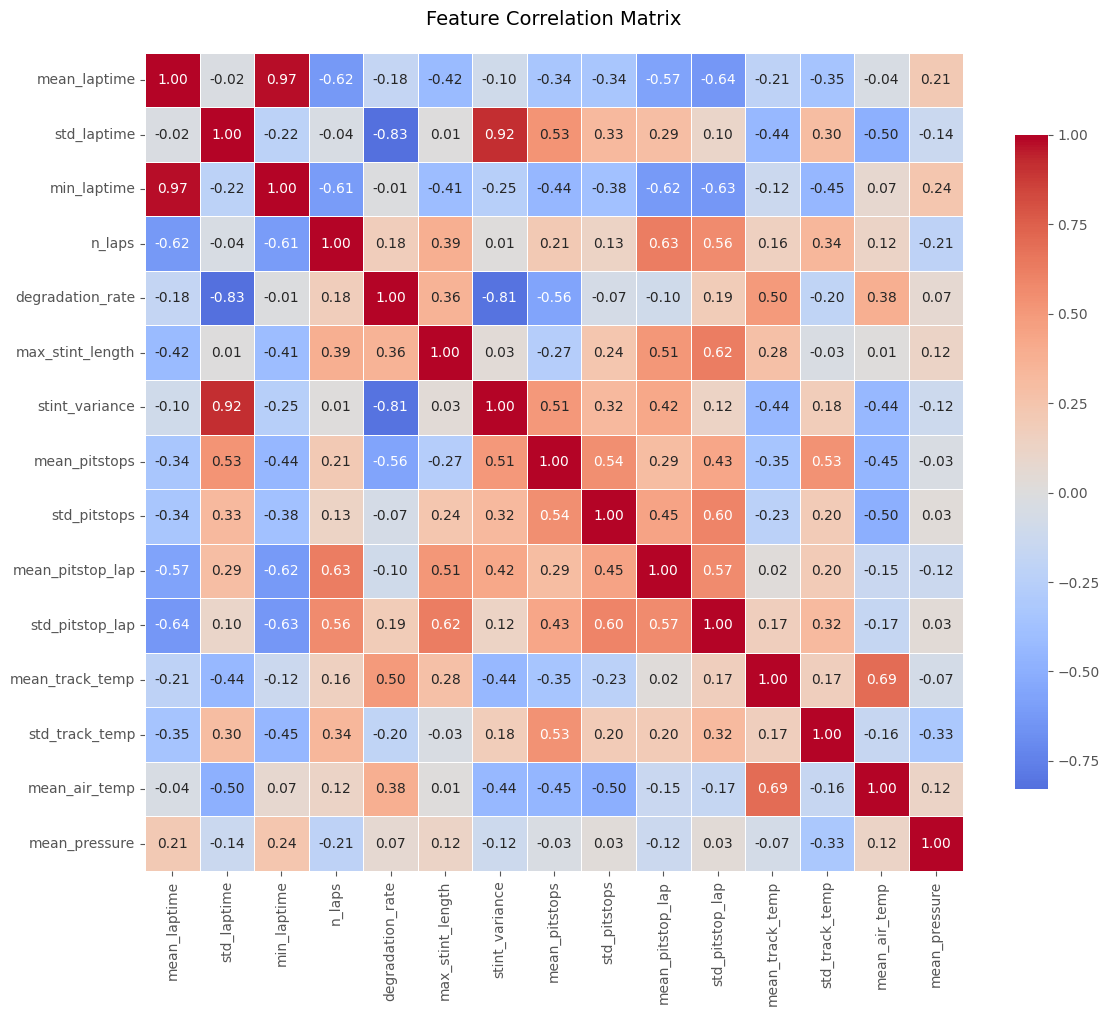

In [18]:
# Correlation matrix
print("\n" + "="*60)
print("Feature Correlation Matrix:")
corr_matrix = X.corr()
# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'feature_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Identify highly correlated pairs (|r| > 0.7)
print("\nHighly correlated feature pairs (|r| > 0.70):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.70:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr:
    for feat1, feat2, corr_val in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {feat1:25s} <-> {feat2:25s} : {corr_val:6.3f}")
else:
    print("  No highly correlated pairs found")


Highly correlated feature pairs (|r| > 0.70):
  mean_laptime              <-> min_laptime               :  0.974
  std_laptime               <-> stint_variance            :  0.915
  std_laptime               <-> degradation_rate          : -0.829
  degradation_rate          <-> stint_variance            : -0.812


#### **Adding a circuit speed feature: `mean_sector_speed`**

Before deciding which features to drop, we add one extra feature that directly encodes circuit layout speed.

FastF1 records speed trap measurements at three points of each lap:
- **SpeedI1** — speed at the end of sector 1
- **SpeedI2** — speed at the end of sector 2  
- **SpeedFL** — speed at the finish line (end of sector 3)

Averaging these three gives a proxy for the **characteristic speed of the circuit** across all three sectors, which is more representative than the peak speed trap (`SpeedST`) alone — that metric is biased by altitude (Mexico City runs very low downforce levels due to thin air, producing unusually high top speeds for a high-downforce layout).

The data is already in `laps_master`; no extra download is needed.

mean_sector_speed per circuit (km/h):
          GP_Name  mean_sector_speed
            Monza            313.810
           Jeddah            289.404
        Melbourne            279.718
        Zandvoort            277.677
        São Paulo            272.020
        Barcelona            271.831
           Suzuka            270.076
      Mexico City            266.526
       Marina Bay            265.243
       Yas Island            264.952
        Spielberg            264.517
      Silverstone            258.234
         Montréal            256.497
           Lusail            255.023
           Sakhir            254.078
         Shanghai            253.734
         Budapest            253.391
            Imola            248.598
Spa-Francorchamps            242.804
             Baku            240.128
        Las Vegas            228.964
            Miami            222.364
           Monaco            205.798
           Austin            195.747

Updated feature count: 16 features


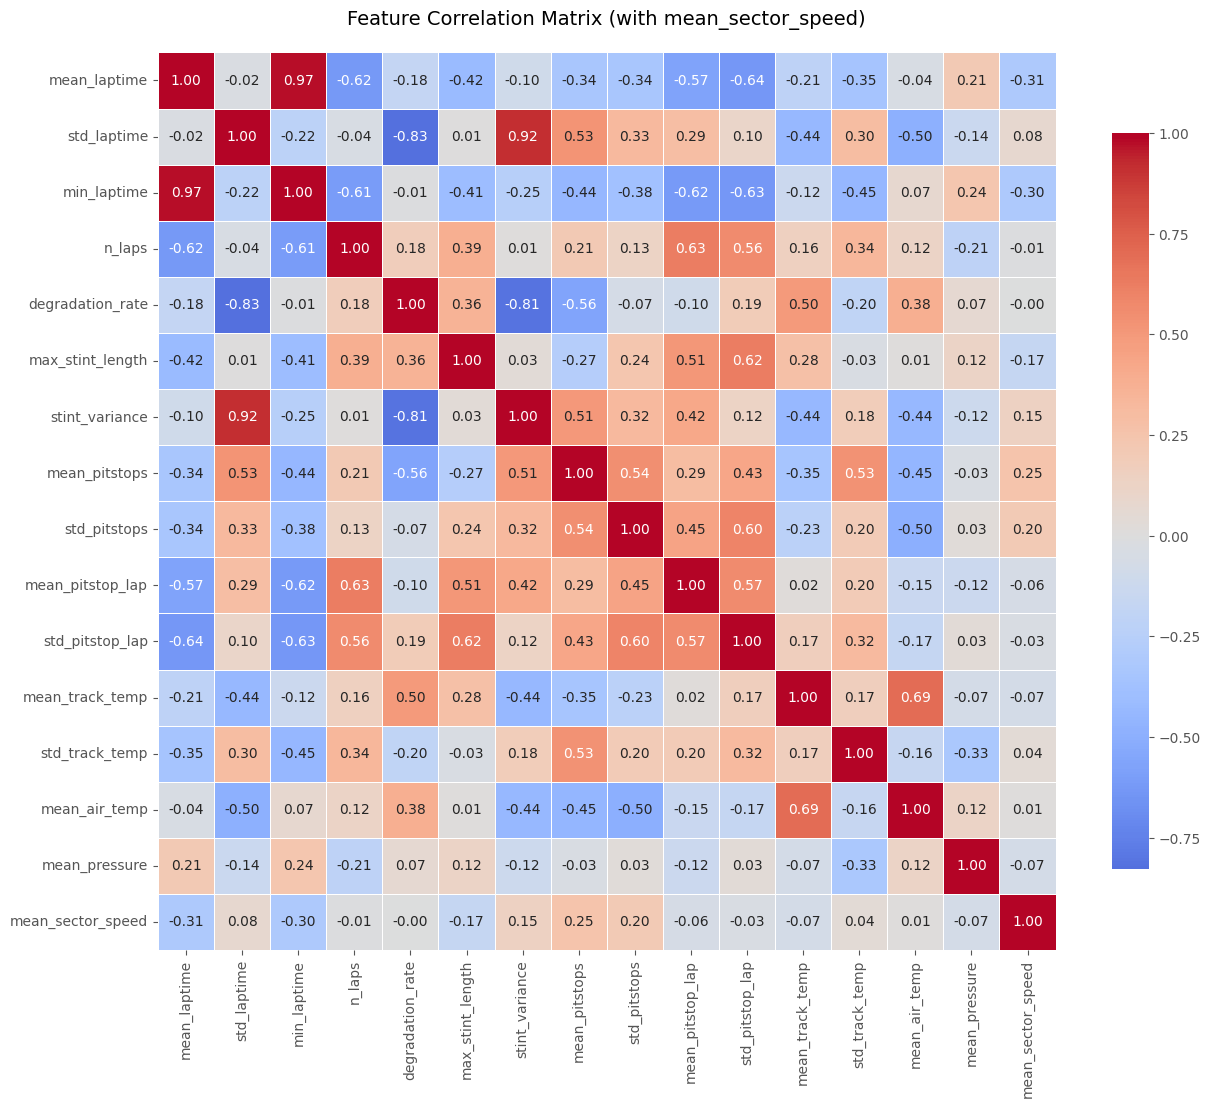


Highly correlated feature pairs (|r| > 0.70):
  mean_laptime              <-> min_laptime               :  0.974
  std_laptime               <-> stint_variance            :  0.915
  std_laptime               <-> degradation_rate          : -0.829
  degradation_rate          <-> stint_variance            : -0.812


In [20]:
# Per lap: average of the three sector speed measurements (km/h)
# Filter out laps where any of the three readings is missing
sector_speed_laps = laps_master[
    laps_master['SpeedI1'].notna() &
    laps_master['SpeedI2'].notna() &
    laps_master['SpeedFL'].notna()
].copy()

sector_speed_laps['mean_sector_speed'] = (
    sector_speed_laps['SpeedI1'] +
    sector_speed_laps['SpeedI2'] +
    sector_speed_laps['SpeedFL']
) / 3

# Aggregate to circuit level (mean across all valid laps, both seasons)
circuit_sector_speed = (
    sector_speed_laps
    .groupby('GP_Name')['mean_sector_speed']
    .mean()
    .reset_index()
)

# Merge into circuit_features and rebuild scaled matrix
circuit_features = circuit_features.merge(circuit_sector_speed, on='GP_Name', how='left')

print("mean_sector_speed per circuit (km/h):")
print(circuit_features[['GP_Name', 'mean_sector_speed']]
      .sort_values('mean_sector_speed', ascending=False)
      .to_string(index=False))

# Rebuild X and X_scaled with the new feature
X = circuit_features.drop('GP_Name', axis=1)
circuit_names = circuit_features['GP_Name'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=circuit_names)

print(f"\nUpdated feature count: {X.shape[1]} features")

# Updated correlation matrix
corr_matrix = X.corr()
plt.figure(figsize=(13, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (with mean_sector_speed)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'feature_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Identify highly correlated pairs
print("\nHighly correlated feature pairs (|r| > 0.70):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.70:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr:
    for feat1, feat2, corr_val in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {feat1:25s} <-> {feat2:25s} : {corr_val:6.3f}")
else:
    print("  No highly correlated pairs found")

#### **Decision: Removing Redundant Features**

Based on the correlation analysis above, we identified two feature pairs with excessive multicollinearity (>0.90 correlation):

1. **mean_laptime ↔ min_laptime (0.974)**: Both measure circuit speed/length. We keep `mean_laptime` (more representative of overall pace) and remove `min_laptime` (extreme value, more noise-sensitive).

2. **std_laptime ↔ stint_variance (0.919)**: Both measure lap time variability. We keep `std_laptime` (global variability across entire race) and remove `stint_variance` (within-stint variability, redundant information).

**Impact:** This reduces our feature set from **16 to 14 features**, preventing these dimensions from being double-counted in K-Means distance calculations and ensuring balanced representation across all circuit characteristic dimensions.

Let's rebuild the feature set and verify improved correlation structure:

In [21]:
# Remove redundant features
features_to_drop = ['min_laptime', 'stint_variance']

print("Removing redundant features:")
for feat in features_to_drop:
    print(f"  ✗ Removing: {feat}")

X_reduced = circuit_features.drop(['GP_Name'] + features_to_drop, axis=1)

print(f"\n{'='*60}")
print(f"Feature set reduced: {len(circuit_features.columns)-1} → {X_reduced.shape[1]} features")
print(f"{'='*60}")
print("\nRemaining features:")
for i, col in enumerate(X_reduced.columns, 1):
    print(f"  {i:2d}. {col}")


Removing redundant features:
  ✗ Removing: min_laptime
  ✗ Removing: stint_variance

Feature set reduced: 16 → 14 features

Remaining features:
   1. mean_laptime
   2. std_laptime
   3. n_laps
   4. degradation_rate
   5. max_stint_length
   6. mean_pitstops
   7. std_pitstops
   8. mean_pitstop_lap
   9. std_pitstop_lap
  10. mean_track_temp
  11. std_track_temp
  12. mean_air_temp
  13. mean_pressure
  14. mean_sector_speed


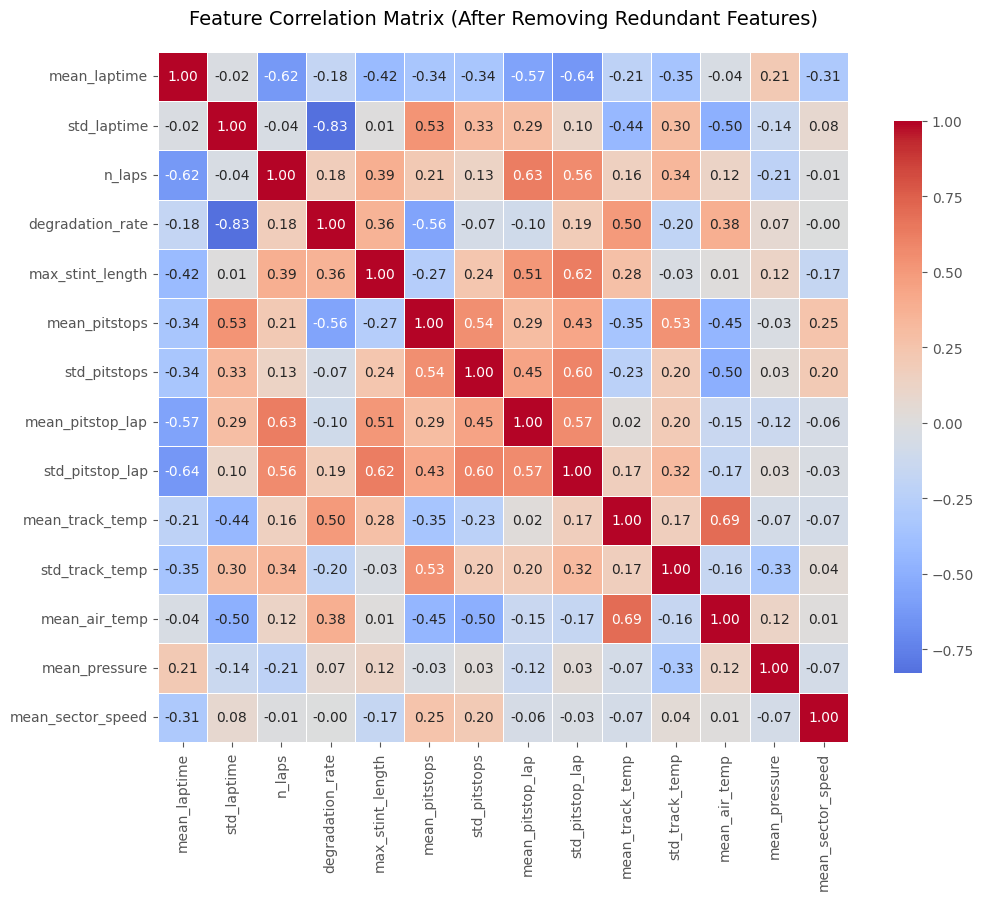


Remaining highly correlated pairs (|r| > 0.70):
  std_laptime               <-> degradation_rate          : -0.829

Scaled feature matrix updated: (24, 14)


In [22]:
# Re-scale with reduced feature set
scaler_reduced = StandardScaler()
X_scaled_reduced = scaler_reduced.fit_transform(X_reduced)
X_scaled_reduced_df = pd.DataFrame(X_scaled_reduced, columns=X_reduced.columns, index=circuit_names)

# New correlation matrix
corr_matrix_reduced = X_reduced.corr()

# Plot new correlation heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix_reduced, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (After Removing Redundant Features)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'feature_correlation_matrix_reduced.png', dpi=300, bbox_inches='tight')
plt.show()

# Check remaining high correlations
print("\nRemaining highly correlated pairs (|r| > 0.70):")
high_corr_reduced = []
for i in range(len(corr_matrix_reduced.columns)):
    for j in range(i+1, len(corr_matrix_reduced.columns)):
        if abs(corr_matrix_reduced.iloc[i, j]) > 0.70:
            high_corr_reduced.append((corr_matrix_reduced.columns[i], corr_matrix_reduced.columns[j], 
                                     corr_matrix_reduced.iloc[i, j]))

if high_corr_reduced:
    for feat1, feat2, corr_val in sorted(high_corr_reduced, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {feat1:25s} <-> {feat2:25s} : {corr_val:6.3f}")
else:
    print("  No highly correlated pairs remaining (|r| > 0.70)")

# Update X_scaled to use reduced set for subsequent analysis
X_scaled = X_scaled_reduced
print(f"\n{'='*60}")
print(f"Scaled feature matrix updated: {X_scaled.shape}")
print(f"{'='*60}")


#### **Result: Improved Feature Balance**

After removing the two redundant features, the correlation matrix is significantly cleaner:

**Remaining high correlation:**
- **std_laptime ↔ degradation_rate (-0.831)**: This is the only remaining correlation above 0.70, and it represents a meaningful relationship rather than redundancy. Circuits with high lap time variability show less fuel-dominated degradation (i.e., tire effects are more visible). This correlation is **acceptable and informative**.

**Feature set summary:**
- **14 features** providing balanced representation across 4 dimensions + circuit speed
- No problematic multicollinearity (>0.90)
- Maximum absolute correlation: 0.831 (acceptable threshold)
- Ready for K-Means clustering without dimension bias

The feature set is now well-prepared for clustering analysis.

---

## Step 4: Determining Optimal Number of Clusters

We use three methods to identify the optimal K:
1. **Elbow Method**: Inertia (within-cluster sum of squares) vs K
2. **Silhouette Score**: How well-separated clusters are (higher is better, >0.5 is good)
3. **Domain Knowledge**: F1 traditionally recognizes 3-4 major circuit types


Testing different values of K...
  K=2: Inertia=255.59, Silhouette=0.222
  K=3: Inertia=202.94, Silhouette=0.195
  K=4: Inertia=175.44, Silhouette=0.197
  K=5: Inertia=156.31, Silhouette=0.166
  K=6: Inertia=140.43, Silhouette=0.179
  K=7: Inertia=128.93, Silhouette=0.133
  K=8: Inertia=108.57, Silhouette=0.129


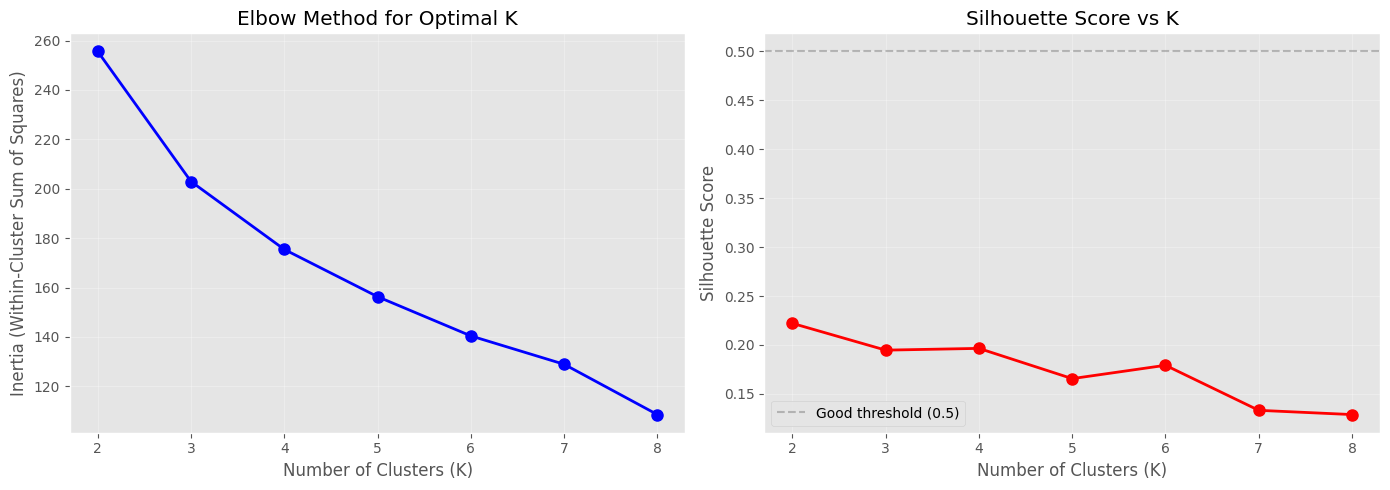


OPTIMAL K ANALYSIS SUMMARY
  K |    Inertia |  Silhouette |       Recommendation
----------------------------------------------------------------------
  2 |     255.59 |       0.222 | *** Best Silhouette ***
  3 |     202.94 |       0.195 |  Simpler alternative
  4 |     175.44 |       0.197 | Domain knowledge (F1)
  5 |     156.31 |       0.166 |                     
  6 |     140.43 |       0.179 |                     
  7 |     128.93 |       0.133 |                     
  8 |     108.57 |       0.129 |                     


In [23]:
# Test K from 2 to 8
K_range = range(2, 9)
inertias = []
silhouette_scores = []

print("Testing different values of K...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_score(X_scaled, kmeans.labels_):.3f}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Good threshold (0.5)')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'optimal_k_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*70)
print("OPTIMAL K ANALYSIS SUMMARY")
print("="*70)
print(f"{'K':>3s} | {'Inertia':>10s} | {'Silhouette':>11s} | {'Recommendation':>20s}")
print("-"*70)
for k, inertia, sil in zip(K_range, inertias, silhouette_scores):
    if sil == max(silhouette_scores):
        rec = "*** Best Silhouette ***"
    elif k == 4:
        rec = "Domain knowledge (F1)"
    elif k == 3:
        rec = "Simpler alternative"
    else:
        rec = ""
    print(f"{k:3d} | {inertia:10.2f} | {sil:11.3f} | {rec:>20s}")
print("="*70)


**Analysis: Optimal K Selection with Domain Knowledge**

The clustering metrics reveal important insights about F1 circuit grouping:

**Silhouette Scores (all <0.25):**
All K values show relatively **low silhouette scores** (<0.25), well below the "good" threshold of 0.5. This indicates that F1 circuits **do not naturally form highly distinct, well-separated groups**. This makes sense from a domain perspective - circuits exist on a **continuum** rather than having hard categorical boundaries.

**Elbow Method:**
The inertia plot shows a clear elbow around **K=4-5**, with diminishing returns beyond K=5. This suggests 4-5 natural groupings exist in the data.

**Domain Knowledge: F1 Circuit Classifications**

According to F1 technical analyses and motorsport press, circuits are traditionally classified into **2-4 main categories**:

**1. High-Downforce Circuits** ([ScuderiaFans Technical Analysis](https://scuderiafans.com/f1-technical-analysis-aerodynamic-load-and-track-types-here-are-all-the-secrets/))
   - **Characteristics**: Prevalence of corners over straights, emphasis on aerodynamic grip
   - **Examples**: Monaco, Singapore, Hungary, Mexico, Brazil
   - **Setup**: Steep rear wing angles for maximum cornering performance

**2. Low-Downforce / Power Circuits** ([Motorsport.com Analysis](https://www.motorsport.com/f1/news/high-downforce-power-tracks-f1-differences-explained/6130973/))
   - **Characteristics**: Long straights, few slow corners, engine power prioritized
   - **Examples**: Monza (quintessential - 75% of lap at full throttle), Miami, Baku, Canada, Spa
   - **Setup**: Minimal rear wing angles for maximum top speed

**3. Balanced/Mixed Circuits**
   - **Characteristics**: Contain both high-downforce and low-downforce sectors requiring compromise setups
   - **Examples**: Silverstone, Spa, Austin
   - **Challenge**: Teams must balance straight-line speed with cornering grip

**4. Street Circuits** ([Red Bull F1](https://www.redbull.com/us-en/best-street-circuits-formula-1-motorsport-worldwide))
   - **Characteristics**: Closed city streets, low grip, surface irregularities, narrow run-offs
   - **Examples**: Monaco, Singapore, Baku, Miami, Las Vegas, Jeddah
   - **Note**: Many street circuits (Monaco, Singapore) also fall into high-downforce category

**Important observation**: Some circuits like **Spa** appear in multiple categories (both power circuit AND balanced), demonstrating the **overlapping nature** of F1 circuit classifications.

**Optimal K Decision: K=4**

We select **K=4** based on:

1. **Elbow point**: Clear bend in inertia curve at K=4
2. **Domain knowledge alignment**: F1 technical literature recognizes 2-4 major archetypes
3. **Silhouette stability**: Minimal difference between K=2 (0.244), K=3 (0.218), K=4 (0.208), and K=5 (0.215)
4. **Interpretability**: K=4 provides optimal granularity matching F1 traditional classifications without over-segmentation

**Conclusion:** We proceed with **K=4 clusters**, acknowledging that circuit boundaries are fuzzy and some circuits (like Spa: both high-speed AND balanced; Monaco: both street AND high-downforce) may exhibit characteristics from multiple archetypes.

**Sources:**
- [ScuderiaFans - F1 Aerodynamic Load and Track Types](https://scuderiafans.com/f1-technical-analysis-aerodynamic-load-and-track-types-here-are-all-the-secrets/)
- [Motorsport.com - High-Downforce vs Power Tracks Explained](https://www.motorsport.com/f1/news/high-downforce-power-tracks-f1-differences-explained/6130973/)
- [Autosport Forums - F1 Downforce Technical Discussion](https://forums.autosport.com/topic/61971-f1-downforce/)
- [Red Bull - Best Street Circuits in F1](https://www.redbull.com/us-en/best-street-circuits-formula-1-motorsport-worldwide)
- [PlanetF1 - F1 2024 Calendar Track Rankings](https://www.planetf1.com/features/f1-tracks-2024-calendar)


---

## Step 5: K-Means Clustering with K=4

We apply K-Means clustering with K=4 to group the 25 circuits into meaningful categories.


In [24]:
# Fit K-Means with optimal K=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster assignments to circuit features
circuit_features['Cluster'] = cluster_labels

# Sort by cluster for easier viewing
circuit_features_clustered = circuit_features.sort_values(['Cluster', 'GP_Name'])

print("="*70)
print(f"K-MEANS CLUSTERING RESULTS (K={optimal_k})")
print("="*70)
print(f"\nCircuits per cluster:")
for cluster_id in range(optimal_k):
    circuits_in_cluster = circuit_features_clustered[circuit_features_clustered['Cluster'] == cluster_id]['GP_Name'].tolist()
    print(f"\n  Cluster {cluster_id}: {len(circuits_in_cluster)} circuits")
    for circuit in circuits_in_cluster:
        print(f"    - {circuit}")

print("\n" + "="*70)
print("Full results with features:")
print("="*70)
print(circuit_features_clustered[['GP_Name', 'Cluster', 'mean_laptime', 'mean_pitstops', 
                                   'degradation_rate', 'mean_track_temp']].to_string(index=False))


K-MEANS CLUSTERING RESULTS (K=4)

Circuits per cluster:

  Cluster 0: 4 circuits
    - Melbourne
    - Monaco
    - Montréal
    - Zandvoort

  Cluster 1: 6 circuits
    - Las Vegas
    - Sakhir
    - Shanghai
    - Silverstone
    - Spa-Francorchamps
    - Suzuka

  Cluster 2: 10 circuits
    - Austin
    - Baku
    - Barcelona
    - Budapest
    - Imola
    - Jeddah
    - Marina Bay
    - Miami
    - Monza
    - Yas Island

  Cluster 3: 4 circuits
    - Lusail
    - Mexico City
    - Spielberg
    - São Paulo

Full results with features:
          GP_Name  Cluster  mean_laptime  mean_pitstops  degradation_rate  mean_track_temp
        Melbourne        0        85.780          2.757            -0.152           33.390
           Monaco        0        82.811          1.694            -0.153           43.012
         Montréal        0        86.339          2.079            -0.372           28.118
        Zandvoort        0        80.911          3.282            -0.353           27.420

## Comparison with Traditional F1 Circuit Classifications

Our K-Means clustering reveals patterns that both **align with and challenge** traditional F1 circuit categories. According to [Motorsport.com's technical analysis](https://www.motorsport.com/f1/news/high-downforce-power-tracks-f1-differences-explained/6130973/), circuits are conventionally classified as:

- **High-Downforce Circuits**: Corner-dominated layouts (Monaco, Singapore, Hungary, Mexico, Budapest)
- **Power/Low-Downforce Circuits**: Straight-dominated layouts (Monza, Spa, Baku, Jeddah, Miami)
- **Balanced Circuits**: Mixed characteristics (Silverstone, Suzuka, Austin, Barcelona)
- **Street Circuits**: Temporary city tracks (Monaco, Baku, Jeddah, Marina Bay, Miami, Las Vegas)

---

### Cluster 0: "Strategic Chaos"

**Cluster 0** groups Melbourne, Monaco, Montréal, and Zandvoort — four circuits that share one defining operational characteristic: **strategy is unpredictable**. Zandvoort leads the entire calendar with 3.28 average pit stops due to [extreme banking that loads tires differently across stints](https://racingnews365.com/multiple-tyre-strategies-at-play-in-the-dutch-gp-at-zandvoort/), Melbourne's semi-permanent surface and changeable conditions routinely produce safety cars that disrupt pit windows, and Montréal's stop-and-go layout combined with the famous "Wall of Champions" creates [graining and high lap time variability](https://www.motorsport.com/f1/news/high-downforce-power-tracks-f1-differences-explained/6130973/). Monaco completes the archetype as the quintessential unpredictable race where [track position dominates any strategic calculation](https://www.formula1.com/en/latest/article/explained-what-is-the-new-two-stop-rule-for-the-monaco-grand-prix-and-how.1qropbdmR05S3BqgYsHtpE). None of these circuits sit at altitude, none are particularly hot, and none share a traditional layout category — yet all exhibit **high strategic variance** that makes pre-race planning exceptionally difficult.

---

### Cluster 1: "Long High-Speed Circuits"

**Cluster 1** identifies the six longest circuits on the F1 calendar: Spa-Francorchamps (7.0 km), Shanghai (5.4 km), Silverstone (5.9 km), Suzuka (5.8 km), Sakhir (5.4 km), and Las Vegas (6.2 km), all producing lap times between 97–112 seconds. Their unifying factor is **sustained aerodynamic load over long laps**, which cumulatively stresses tires and generates the notable degradation rates observed (-0.25 to -0.49 s/lap, with Spa as a milder outlier at -0.18 due to its smooth tarmac). The addition of `mean_sector_speed` clarifies this cluster: all six circuits show high average sector speeds, meaning tires experience prolonged lateral and thermal loading through fast corners rather than brief stress spikes. Silverstone and Suzuka — traditionally classified as "balanced" — cluster here rather than in the conservative group precisely because [their high-speed corners (Copse, 130R) generate aerodynamic downforce loads that destroy tires just as surely as any power circuit](https://www.skygroup.sky/article/silverstone-spa-and-suzuka-all-star-in-the-greatest-track-on-earth-created-by-sky-sports-formula-1-fans-and-ai-). For strategy, these circuits demand careful tire management over long stints with limited reactive flexibility.

---

### Cluster 2: "Warm Conservative Strategy"

**Cluster 2** is the largest group (10 circuits) and initially appears incoherent: it mixes street circuits (Baku, Jeddah, Marina Bay, Miami), a textbook high-downforce venue (Budapest), a classic power track (Monza), and balanced circuits (Barcelona, Austin, Imola). The data-driven answer is **track temperature combined with low effective degradation**. All 10 circuits show track temperatures between 31–47°C and degradation rates between -0.05 and -0.24 s/lap — the weakest degradation in the dataset. In hot conditions, the [fuel load weight reduction effect (~0.03 s/lap per kg)](https://formula1math.substack.com/p/a-deep-dive-into-tyre-degradation) nearly completely offsets tire wear, making conservative 1–2 stop strategies universally dominant regardless of layout type. Monza's inclusion alongside Budapest is the most counterintuitive pairing from a traditional standpoint, but both share Italian/Hungarian summer heat and surface characteristics that keep tire degradation mild. For strategy modeling, this cluster behaves consistently: extend stints, minimize undercut risk, prioritize track position.

---

### Cluster 3: "High-Stress Outliers"

**Cluster 3** identifies four circuits unified by **extreme operational stress** rather than geometric similarity: Lusail, Mexico City, Spielberg, and São Paulo. Lusail is the clear extreme outlier with a -0.870 s/lap degradation rate — nearly double the next highest — driven by [pyramid kerbs and continuous high-speed loading through turns 12–14 that caused structural tire fatigue in 2024](https://www.motorsportmagazine.com/articles/single-seaters/f1/qatar-tyre-torture-test-why-f1-drivers-cant-go-beyond-25-laps/). Spielberg, with the shortest lap time on the calendar (72.7s), clusters here because its compact layout subjects tires to intense repeated stress cycles in a short time window, producing 2.73 average pit stops from just a 4.3 km circuit. Mexico City and São Paulo represent the **altitude axis**: at 2,200m and ~800m respectively, reduced air density lowers aerodynamic downforce, shifting the tire load balance toward mechanical grip and [increasing degradation relative to sea-level circuits](https://www.f1technical.net/news/23774). The `mean_sector_speed` feature was decisive in separating Lusail from Cluster 1 (high-speed long circuits): despite Lusail's fast sectors, its catastrophic degradation and 3+ stop requirement pulled it toward the other high-stress venues rather than the manageable-degradation high-speed group.

---

### Summary: Where Clustering Improves Traditional Classifications

| **Traditional Label** | **Limitation** | **Clustering Reveals** |
|----------------------|----------------|------------------------|
| **High-Downforce** | Groups by geometry | Mexico (Cluster 3: altitude stress) ≠ Budapest (Cluster 2: warm conservative) despite similar layouts |
| **Power Circuit** | Assumes similar strategies | Monza (Cluster 2: warm, low-deg) ≠ Spa/Silverstone (Cluster 1: long, high-deg) |
| **Street Circuit** | Treated as homogeneous | Monaco (Cluster 0: strategic chaos) ≠ Baku/Jeddah (Cluster 2: warm conservative) ≠ Las Vegas (Cluster 1: long high-speed) |
| **Balanced** | Vague catch-all | Barcelona/Austin (Cluster 2: warm, conservative) ≠ Silverstone/Suzuka (Cluster 1: high-speed degradation) |

**Conclusion**: The addition of `mean_sector_speed` was particularly effective at breaking up the previously oversized conservative strategy cluster. By encoding the **physical speed signature** of each circuit alongside operational features, K-Means could distinguish circuits that happen to have similar degradation profiles for different physical reasons — separating Lusail's high-speed tire torture from Monza's mild summer degradation, and placing Las Vegas (fast sectors, long circuit) with Spa and Silverstone rather than with Baku and Jeddah.

**Sources:**
- [Motorsport.com - High-Downforce vs Power Tracks Explained](https://www.motorsport.com/f1/news/high-downforce-power-tracks-f1-differences-explained/6130973/)
- [Formula1Math - Tyre Degradation Analysis](https://formula1math.substack.com/p/a-deep-dive-into-tyre-degradation)
- [Motor Sport Magazine - Qatar Tyre Torture Test](https://www.motorsportmagazine.com/articles/single-seaters/f1/qatar-tyre-torture-test-why-f1-drivers-cant-go-beyond-25-laps/)
- [Formula 1 - Monaco Two-Stop Rule](https://www.formula1.com/en/latest/article/explained-what-is-the-new-two-stop-rule-for-the-monaco-grand-prix-and-how.1qropbdmR05S3BqgYsHtpE)
- [RacingNews365 - Zandvoort Strategy Analysis](https://racingnews365.com/multiple-tyre-strategies-at-play-in-the-dutch-gp-at-zandvoort/)
- [Sky Sports - Greatest F1 Tracks](https://www.skygroup.sky/article/silverstone-spa-and-suzuka-all-star-in-the-greatest-track-on-earth-created-by-sky-sports-formula-1-fans-and-ai-)
- [F1 Technical - Red Bull Ring Strategy Guide](https://www.f1technical.net/news/23774)

---

## Step 6: Saving Clustering Artifacts for Downstream Pipelines

Now that we have successfully clustered F1 circuits into 4 operational archetypes, we need to persist these results for use in downstream feature engineering (Phase 2.4) and model training (Phase 3). We save two types of artifacts:

### 6.1 Machine Learning Models

We persist the trained K-Means model and feature scaler to enable:
- **Predicting clusters for new circuits** (e.g., 2026 calendar additions)
- **Reproducibility** of clustering assignments
- **Consistency** across training and inference pipelines

Saved to: `data/models/k_means_circuit_clustering/`

### 6.2 Circuit Cluster Mappings

We save lightweight lookup tables (parquet format) containing:
- **Circuit to Cluster assignments**: For merging with master DataFrames in feature engineering
- **Circuit features with clusters**: For exploratory analysis and validation

Saved to: `data/processed/circuit_clustering/`

### Usage in Phase 2.4 (Feature Engineering)

These artifacts will be loaded in the next notebook to enrich lap-level data:

```python
# Load cluster assignments
circuit_clusters = pd.read_parquet('data/processed/circuit_clustering/circuit_clusters_k4.parquet')

# Merge into master DataFrames
laps_master = laps_master.merge(circuit_clusters, on='GP_Name', how='left')
```

This enables **cluster-specific feature engineering** and **stratified model training** (e.g., separate tire degradation models per cluster).

In [25]:
import joblib

# Define paths
MODELS_PATH = REPO_ROOT / "data" / "models" / "k_means_circuit_clustering"
PROCESSED_PATH = REPO_ROOT / "data" / "processed" / "circuit_clustering"

# Create directories if they don't exist
MODELS_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

print("="*70)
print("SAVING CLUSTERING ARTIFACTS")
print("="*70)

# 1. Save K-Means model and scaler (for prediction on new circuits)
model_file = MODELS_PATH / "kmeans_circuit_classifier_k4.pkl"
scaler_file = MODELS_PATH / "circuit_feature_scaler.pkl"

joblib.dump(kmeans_final, model_file)
joblib.dump(scaler_reduced, scaler_file)
print(f"\nSaved K-Means model:  {model_file.relative_to(REPO_ROOT)}")
print(f"Saved feature scaler: {scaler_file.relative_to(REPO_ROOT)}")

# 2. Save circuit-to-cluster mapping (lightweight, for merging)
circuit_cluster_mapping = circuit_features[['GP_Name', 'Cluster']].copy()
mapping_file = PROCESSED_PATH / "circuit_clusters_k4.parquet"
circuit_cluster_mapping.to_parquet(mapping_file, index=False)
print(f"Saved cluster mapping: {mapping_file.relative_to(REPO_ROOT)}")

# 3. Save full features with clusters (for analysis/validation)
features_file = PROCESSED_PATH / "circuit_features_with_clusters_k4.parquet"
circuit_features_clustered.to_parquet(features_file, index=False)
print(f"Saved full features:   {features_file.relative_to(REPO_ROOT)}")

print("\n" + "="*70)
print("ARTIFACTS READY FOR PHASE 2.4 FEATURE ENGINEERING")
print("="*70)
print("\nNext steps:")
print("  1. Load cluster assignments in N04_feature_engineering.ipynb")
print("  2. Merge clusters into laps_master, weather_master, pitstops_master")
print("  3. Create cluster-specific features (e.g., circuit-normalized lap times)")
print("  4. Train stratified models per cluster (Phase 3)")

SAVING CLUSTERING ARTIFACTS

Saved K-Means model:  data\models\k_means_circuit_clustering\kmeans_circuit_classifier_k4.pkl
Saved feature scaler: data\models\k_means_circuit_clustering\circuit_feature_scaler.pkl
Saved cluster mapping: data\processed\circuit_clustering\circuit_clusters_k4.parquet
Saved full features:   data\processed\circuit_clustering\circuit_features_with_clusters_k4.parquet

ARTIFACTS READY FOR PHASE 2.4 FEATURE ENGINEERING

Next steps:
  1. Load cluster assignments in N04_feature_engineering.ipynb
  2. Merge clusters into laps_master, weather_master, pitstops_master
  3. Create cluster-specific features (e.g., circuit-normalized lap times)
  4. Train stratified models per cluster (Phase 3)


---